## Step 3: Modeling Setup (Strict Pre-Contact)
### - Drop leakage-prone variables: `duration`, `campaign`
### - Define X and y (`deposit` if present, else `y`)
### - Stratified 80/20 train-test split
### - Verify class proportions in train/test

In [69]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Path (edit if needed)
DATA_PATH = "/Users/chiying/Documents/Predictive-Individual-Coursework/data/bank.csv"

# Load data
df = pd.read_csv(DATA_PATH)

# Detect target column
if "deposit" in df.columns:
    target_col = "deposit"
elif "y" in df.columns:
    target_col = "y"
else:
    print("Target column not found. Available columns:")
    print(df.columns.tolist())
    raise SystemExit("Stopping: neither 'deposit' nor 'y' exists.")

print(f"Detected target column: {target_col}")

# Drop leakage-prone columns for strict pre-contact setting
drop_cols = [c for c in ["duration", "campaign"] if c in df.columns]
df_model = df.drop(columns=drop_cols).copy()

print("Dropped columns:", drop_cols if drop_cols else "None (not found)")

# Define X and y
X = df_model.drop(columns=[target_col])
y = df_model[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nSplit sizes:")
print(f"Train: {X_train.shape[0]} rows")
print(f"Test:  {X_test.shape[0]} rows")

# Verify class proportions
train_props = y_train.value_counts(normalize=True, dropna=False).sort_index()
test_props = y_test.value_counts(normalize=True, dropna=False).sort_index()
full_props = y.value_counts(normalize=True, dropna=False).sort_index()

print("\nClass proportions (full dataset):")
print(full_props.round(4))

print("\nClass proportions (train):")
print(train_props.round(4))

print("\nClass proportions (test):")
print(test_props.round(4))

Detected target column: deposit
Dropped columns: ['duration', 'campaign']
X shape: (11162, 14)
y shape: (11162,)

Split sizes:
Train: 8929 rows
Test:  2233 rows

Class proportions (full dataset):
deposit
no     0.5262
yes    0.4738
Name: proportion, dtype: float64

Class proportions (train):
deposit
no     0.5262
yes    0.4738
Name: proportion, dtype: float64

Class proportions (test):
deposit
no     0.5262
yes    0.4738
Name: proportion, dtype: float64


### Feature audit before modeling (no dataset modification)
### Prints final feature list from `X`, classifies each feature, and confirms pre-contact availability.

In [70]:
if "X" not in globals():
    if "deposit" in df.columns:
        target_col = "deposit"
    elif "y" in df.columns:
        target_col = "y"
    else:
        print("Target column not found. Available columns:")
        print(df.columns.tolist())
        raise SystemExit("Stopping: neither 'deposit' nor 'y' exists.")
    X = df.drop(columns=[c for c in [target_col, "duration", "campaign"] if c in df.columns])

print("Final feature columns used in X:")
print(X.columns.tolist())

# Classification map for bank dataset fields (strict pre-contact framing)
feature_class = {
    "age": "demographic",
    "job": "demographic",
    "marital": "demographic",
    "education": "demographic",
    "default": "financial",
    "balance": "financial",
    "housing": "financial",
    "loan": "financial",
    "contact": "historical campaign",
    "day": "historical campaign",
    "month": "historical campaign",
    "pdays": "historical campaign",
    "previous": "historical campaign",
    "poutcome": "historical campaign",
}

# Availability under strict pre-contact setting
# (Assumes these values are known at decision time from profile/history/campaign plan)
availability_pre_first_contact = {
    "age": True,
    "job": True,
    "marital": True,
    "education": True,
    "default": True,
    "balance": True,
    "housing": True,
    "loan": True,
    "contact": True,   # if contact channel is decided before outreach
    "day": True,       # if contact date is scheduled/planned
    "month": True,     # if contact month is scheduled/planned
    "pdays": True,     # historical prior-campaign info (if exists)
    "previous": True,  # historical prior-campaign info (if exists)
    "poutcome": True,  # historical prior-campaign info (if exists)
}

notes = {
    "contact": "Planned channel should be fixed before outreach.",
    "day": "Use only if planned date is known before contact attempt.",
    "month": "Use only if planned month is known before contact attempt.",
    "pdays": "Represents past campaign history; for no history, sentinel values may appear.",
    "previous": "Represents count of prior contacts from past campaigns.",
    "poutcome": "Outcome from previous campaign interactions only.",
}

audit_rows = []
for col in X.columns:
    audit_rows.append({
        "feature": col,
        "type": feature_class.get(col, "historical campaign"),
        "available_prior_to_first_contact": availability_pre_first_contact.get(col, True),
        "note": notes.get(col, "")
    })

audit_df = pd.DataFrame(audit_rows).sort_values("feature").reset_index(drop=True)

print("\nFeature classification and strict pre-contact availability:")
print(audit_df.to_string(index=False))


Final feature columns used in X:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'pdays', 'previous', 'poutcome']

Feature classification and strict pre-contact availability:
  feature                type  available_prior_to_first_contact                                                                          note
      age         demographic                              True                                                                              
  balance           financial                              True                                                                              
  contact historical campaign                              True                              Planned channel should be fixed before outreach.
      day historical campaign                              True                     Use only if planned date is known before contact attempt.
  default           financial                           

## Leakage-oriented feature association scan (no model training)
### Goal:
### - Compute association strength between each feature and target (`y_bin`)
### - Use mutual information across all features
### - Add simple association metrics (numeric correlation, categorical rate spread)
### - Flag features that look suspiciously predictive

In [71]:
from sklearn.feature_selection import mutual_info_classif

if "df" not in globals():
    DATA_PATH = "./data/bank.csv"
    df = pd.read_csv(DATA_PATH)

if "target_col" not in globals():
    if "deposit" in df.columns:
        target_col = "deposit"
    elif "y" in df.columns:
        target_col = "y"
    else:
        print("Target column not found. Available columns:")
        print(df.columns.tolist())
        raise SystemExit("Stopping: neither 'deposit' nor 'y' exists.")

if "X" not in globals():
    X = df.drop(columns=[c for c in [target_col, "duration", "campaign"] if c in df.columns])

# Binary target for association calculations
y_bin = df[target_col].astype(str).str.strip().str.lower().eq("yes").astype(int)

print(f"Using target: {target_col}")
print(f"Number of features in X: {X.shape[1]}")


Using target: deposit
Number of features in X: 14


## 1) Mutual Information for all features
### Mixed-type handling:
### - categorical -> category codes
### - numeric -> keep numeric (fill missing with median)
### - MI computed with `mutual_info_classif`

In [72]:
X_mi = X.copy()
cat_cols = X_mi.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = [c for c in X_mi.columns if c not in cat_cols]

# Encode categorical as integer codes (missing -> -1)
for c in cat_cols:
    X_mi[c] = X_mi[c].astype("category").cat.codes

# Fill numeric missing values with median
for c in num_cols:
    X_mi[c] = pd.to_numeric(X_mi[c], errors="coerce")
    X_mi[c] = X_mi[c].fillna(X_mi[c].median())

# Ensure categorical encoded cols have no NA
for c in cat_cols:
    X_mi[c] = X_mi[c].fillna(-1)

discrete_mask = [col in cat_cols for col in X_mi.columns]

mi = mutual_info_classif(
    X_mi,
    y_bin,
    discrete_features=discrete_mask,
    random_state=42
)

mi_df = pd.DataFrame({
    "feature": X_mi.columns,
    "mutual_information": mi
}).sort_values("mutual_information", ascending=False).reset_index(drop=True)

print("Mutual Information ranking:")
print(mi_df)

Mutual Information ranking:
      feature  mutual_information
0    poutcome            0.050386
1       month            0.050114
2     balance            0.047730
3       pdays            0.045879
4     contact            0.034722
5    previous            0.029604
6         age            0.024938
7     housing            0.020952
8         day            0.018016
9         job            0.017244
10       loan            0.006244
11  education            0.005513
12    marital            0.004911
13    default            0.000853


## 2) Simple association metrics
### - Numeric features: absolute Pearson correlation with `y_bin`
### - Categorical features: positive-rate spread across categories (`max(rate)-min(rate)`)

In [73]:
# Numeric correlation
num_assoc_rows = []
for c in num_cols:
    s = pd.to_numeric(X[c], errors="coerce")
    valid = s.notna()
    if valid.sum() > 1:
        corr = s[valid].corr(y_bin[valid])
    else:
        corr = float("nan")
    num_assoc_rows.append({
        "feature": c,
        "metric": "abs_pearson_corr_with_target",
        "value": abs(corr) if pd.notna(corr) else float("nan"),
        "support": int(valid.sum())
    })

# Categorical rate spread
cat_assoc_rows = []
for c in cat_cols:
    tmp = pd.DataFrame({"feat": X[c], "y_bin": y_bin}).dropna(subset=["feat"])
    if tmp.empty:
        spread = float("nan")
        n_levels = 0
    else:
        rates = tmp.groupby("feat")["y_bin"].mean()
        spread = rates.max() - rates.min() if len(rates) > 1 else 0.0
        n_levels = len(rates)
    cat_assoc_rows.append({
        "feature": c,
        "metric": "target_rate_spread_by_category",
        "value": spread,
        "support": int(tmp.shape[0]),
        "n_levels": n_levels
    })

num_assoc_df = pd.DataFrame(num_assoc_rows).sort_values("value", ascending=False)
cat_assoc_df = pd.DataFrame(cat_assoc_rows).sort_values("value", ascending=False)

print("\nNumeric association (abs Pearson correlation):")
print(num_assoc_df)

print("\nCategorical association (target-rate spread):")
print(cat_assoc_df)


Numeric association (abs Pearson correlation):
    feature                        metric     value  support
3     pdays  abs_pearson_corr_with_target  0.151593    11162
4  previous  abs_pearson_corr_with_target  0.139867    11162
1   balance  abs_pearson_corr_with_target  0.081129    11162
2       day  abs_pearson_corr_with_target  0.056326    11162
0       age  abs_pearson_corr_with_target  0.034901    11162

Categorical association (target-rate spread):
     feature                          metric     value  support  n_levels
7      month  target_rate_spread_by_category  0.581541    11162        12
8   poutcome  target_rate_spread_by_category  0.506487    11162         4
0        job  target_rate_spread_by_category  0.383025    11162        12
6    contact  target_rate_spread_by_category  0.317356    11162         3
4    housing  target_rate_spread_by_category  0.203903    11162         2
3    default  target_rate_spread_by_category  0.166827    11162         2
5       loan  target_

## 3) Suspiciously predictive feature flags
### Data-driven + simple rule-based flagging:
### - MI >= 95th percentile (top tail)
### - Numeric abs corr >= 0.30
### - Categorical rate spread >= 0.40 with at least 100 records

In [74]:
mi_threshold = mi_df["mutual_information"].quantile(0.95)
suspicious_from_mi = mi_df[mi_df["mutual_information"] >= mi_threshold].copy()
suspicious_from_mi["flag_reason"] = f"MI in top 5% (>= {mi_threshold:.4f})"

suspicious_num = num_assoc_df[num_assoc_df["value"] >= 0.30].copy()
suspicious_num["flag_reason"] = "High absolute Pearson correlation (>= 0.30)"

if not cat_assoc_df.empty:
    suspicious_cat = cat_assoc_df[
        (cat_assoc_df["value"] >= 0.40) & (cat_assoc_df["support"] >= 100)
    ].copy()
    suspicious_cat["flag_reason"] = "Large category rate spread (>= 0.40)"
else:
    suspicious_cat = pd.DataFrame(columns=["feature", "metric", "value", "support", "n_levels", "flag_reason"])

flag_tables = []

if not suspicious_from_mi.empty:
    flag_tables.append(
        suspicious_from_mi[["feature", "mutual_information", "flag_reason"]]
        .rename(columns={"mutual_information": "score"})
        .assign(metric="mutual_information")
    )

if not suspicious_num.empty:
    flag_tables.append(
        suspicious_num[["feature", "metric", "value", "flag_reason"]]
        .rename(columns={"value": "score"})
    )

if not suspicious_cat.empty:
    flag_tables.append(
        suspicious_cat[["feature", "metric", "value", "flag_reason"]]
        .rename(columns={"value": "score"})
    )

if flag_tables:
    suspicious_flags = pd.concat(flag_tables, ignore_index=True)
    suspicious_flags = suspicious_flags.sort_values("score", ascending=False)
    print("\nPotentially suspiciously predictive features:")
    print(suspicious_flags)
else:
    print("\nNo features crossed the current suspicion thresholds.")

# Optional: quick combined table for review
assoc_summary = mi_df.merge(
    num_assoc_df[["feature", "value"]].rename(columns={"value": "abs_pearson_corr"}),
    on="feature",
    how="left"
).merge(
    cat_assoc_df[["feature", "value"]].rename(columns={"value": "cat_rate_spread"}),
    on="feature",
    how="left"
)

print("\nCombined association summary:")
print(assoc_summary.sort_values("mutual_information", ascending=False))


Potentially suspiciously predictive features:
    feature     score                           flag_reason  \
1     month  0.581541  Large category rate spread (>= 0.40)   
2  poutcome  0.506487  Large category rate spread (>= 0.40)   
0  poutcome  0.050386              MI in top 5% (>= 0.0502)   

                           metric  
1  target_rate_spread_by_category  
2  target_rate_spread_by_category  
0              mutual_information  

Combined association summary:
      feature  mutual_information  abs_pearson_corr  cat_rate_spread
0    poutcome            0.050386               NaN         0.506487
1       month            0.050114               NaN         0.581541
2     balance            0.047730          0.081129              NaN
3       pdays            0.045879          0.151593              NaN
4     contact            0.034722               NaN         0.317356
5    previous            0.029604          0.139867              NaN
6         age            0.024938         

## Create Two Feature Sets for Strict Pre-Contact Modeling
### - Set A (baseline strict): drop `duration`, `campaign`
### - Set B (extra strict): drop `duration`, `campaign`, `day`, `month`, `contact`
### - Print final feature list and X shape for each
### - No model training

In [75]:
if "df" not in globals():
    DATA_PATH = "./data/bank.csv"
    df = pd.read_csv(DATA_PATH)

# Detect target column
if "deposit" in df.columns:
    target_col = "deposit"
elif "y" in df.columns:
    target_col = "y"
else:
    print("Target column not found. Available columns:")
    print(df.columns.tolist())
    raise SystemExit("Stopping: neither 'deposit' nor 'y' exists.")

print(f"Detected target column: {target_col}")

# Define drop lists
drop_set_a = ["duration", "campaign"]
drop_set_b = ["duration", "campaign", "day", "month", "contact"]

# Keep only columns that exist
drop_set_a_present = [c for c in drop_set_a if c in df.columns]
drop_set_b_present = [c for c in drop_set_b if c in df.columns]

# Build feature sets (without modifying original df)
X_set_a = df.drop(columns=[target_col] + drop_set_a_present)
X_set_b = df.drop(columns=[target_col] + drop_set_b_present)

# Print results: Set A
print("\n" + "=" * 80)
print("Set A (baseline strict): drop duration + campaign")
print("=" * 80)
print("Dropped columns:", drop_set_a_present)
print("X_set_a shape:", X_set_a.shape)
print("Final feature list (Set A):")
print(X_set_a.columns.tolist())

# Print results: Set B
print("\n" + "=" * 80)
print("Set B (extra strict): drop duration + campaign + day + month + contact")
print("=" * 80)
print("Dropped columns:", drop_set_b_present)
print("X_set_b shape:", X_set_b.shape)
print("Final feature list (Set B):")
print(X_set_b.columns.tolist())

# Optional: keep target available for next steps
y = df[target_col].copy()
print("\ny shape:", y.shape)

Detected target column: deposit

Set A (baseline strict): drop duration + campaign
Dropped columns: ['duration', 'campaign']
X_set_a shape: (11162, 14)
Final feature list (Set A):
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'pdays', 'previous', 'poutcome']

Set B (extra strict): drop duration + campaign + day + month + contact
Dropped columns: ['duration', 'campaign', 'day', 'month', 'contact']
X_set_b shape: (11162, 11)
Final feature list (Set B):
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'pdays', 'previous', 'poutcome']

y shape: (11162,)


## Reproducible Preprocessing + Logistic Pipeline (Strict Pre-Contact)
### - Target: `deposit` else `y`
### - Feature Set A: drop `duration`, `campaign`
### - Feature Set B: drop `duration`, `campaign`, `day`, `month`, `contact`
### - Splits: stratified `train_val/test = 80/20`, then `train/val = 80/20` within train_val
### - Model: `Pipeline(preprocess -> LogisticRegression)`
### - Libraries: pandas, numpy, scikit-learn only

In [76]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Reproducibility
RANDOM_STATE = 42

# User-editable path
DATA_PATH = "/Users/chiying/Documents/Predictive-Individual-Coursework/data/bank.csv"

# Optional preprocessing choices
USE_SCALER = True  # set False to skip StandardScaler for numeric features
CAT_IMPUTE_STRATEGY = "most_frequent"  # choose: "most_frequent" or "constant"
CAT_IMPUTE_CONSTANT = "unknown"        # used if CAT_IMPUTE_STRATEGY == "constant"

# %%
# Load data
df = pd.read_csv(DATA_PATH)
print("Loaded shape:", df.shape)

# Detect target
if "deposit" in df.columns:
    TARGET_COL = "deposit"
elif "y" in df.columns:
    TARGET_COL = "y"
else:
    print("Target not found. Available columns:")
    print(df.columns.tolist())
    raise SystemExit("Stopping: neither 'deposit' nor 'y' exists.")

print("Target column:", TARGET_COL)


Loaded shape: (11162, 17)
Target column: deposit


## Basic data quality checks (before splitting)
### - Missingness summary
### - 'unknown' placeholder summary for categorical columns

In [77]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2)
}).sort_values("missing_pct", ascending=False)

print("Missingness summary:")
print(missing_summary)

cat_cols_all = df.select_dtypes(include=["object", "category"]).columns.tolist()
unknown_rows = []
for c in cat_cols_all:
    unknown_count = df[c].astype(str).str.strip().str.lower().eq("unknown").sum()
    unknown_rows.append({
        "column": c,
        "unknown_count": int(unknown_count),
        "unknown_pct": round(100 * unknown_count / len(df), 2)
    })
unknown_summary = pd.DataFrame(unknown_rows).sort_values("unknown_pct", ascending=False)

print("\n'unknown' summary (categorical columns):")
print(unknown_summary)

# %%
def class_proportions(y: pd.Series) -> pd.Series:
    return y.value_counts(normalize=True, dropna=False).sort_index()

def print_split_info(name: str, X_part: pd.DataFrame, y_part: pd.Series) -> None:
    print(f"{name} X shape: {X_part.shape}, y shape: {y_part.shape}")
    print(f"{name} class proportions:")
    print(class_proportions(y_part).round(4))
    print("-" * 60)

def build_model_pipeline(X_train: pd.DataFrame) -> Pipeline:
    # Identify column types from training data only (good practice)
    numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

    if CAT_IMPUTE_STRATEGY == "constant":
        cat_imputer = SimpleImputer(strategy="constant", fill_value=CAT_IMPUTE_CONSTANT)
    else:
        cat_imputer = SimpleImputer(strategy="most_frequent")

    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if USE_SCALER:
        num_steps.append(("scaler", StandardScaler()))

    numeric_transformer = Pipeline(steps=num_steps)
    categorical_transformer = Pipeline(steps=[
        ("imputer", cat_imputer),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocess = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ],
        remainder="drop"
    )

    model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)

    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])
    return pipe

def run_feature_set(df_in: pd.DataFrame, target_col: str, set_name: str, drop_cols: list[str]) -> dict:
    print("\n" + "=" * 80)
    print(f"Feature Set {set_name}")
    print("=" * 80)

    # Keep only columns that exist
    drops_present = [c for c in drop_cols if c in df_in.columns]

    # Build X, y
    X = df_in.drop(columns=[target_col] + drops_present).copy()
    y = df_in[target_col].copy()

    # Leakage asserts
    for c in drops_present:
        assert c not in X.columns, f"Leakage check failed: {c} still in X"
    assert target_col not in X.columns, "Schema check failed: target still in X"

    # Basic schema checks
    assert X.shape[0] == y.shape[0], "Schema check failed: X/y row mismatch"
    assert X.columns.is_unique, "Schema check failed: duplicate feature names"
    assert X.shape[1] > 0, "Schema check failed: no features left"

    print("Dropped columns:", drops_present)
    print("Final feature count:", X.shape[1])
    print("Final feature list:")
    print(X.columns.tolist())

    # 1) train_val/test split (80/20), stratified
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y
    )

    # 2) train/val split inside train_val (80/20), stratified
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_train_val
    )

    print("\nSplit diagnostics:")
    print_split_info("Train", X_train, y_train)
    print_split_info("Val", X_val, y_val)
    print_split_info("Test", X_test, y_test)

    # Fit pipeline on TRAIN only
    pipeline = build_model_pipeline(X_train)
    pipeline.fit(X_train, y_train)

    # Predict probabilities on val/test
    val_proba = pipeline.predict_proba(X_val)
    test_proba = pipeline.predict_proba(X_test)

    proba_cols = [f"proba_{cls}" for cls in pipeline.named_steps["model"].classes_]
    val_proba_df = pd.DataFrame(val_proba, columns=proba_cols, index=X_val.index)
    test_proba_df = pd.DataFrame(test_proba, columns=proba_cols, index=X_test.index)

    print("First 5 rows of predict_proba on VAL:")
    print(val_proba_df.head(5))

    print("\nFirst 5 rows of predict_proba on TEST:")
    print(test_proba_df.head(5))

    return {
        "set_name": set_name,
        "drops_present": drops_present,
        "X_columns": X.columns.tolist(),
        "X_shapes": {
            "train": X_train.shape,
            "val": X_val.shape,
            "test": X_test.shape
        },
        "pipeline": pipeline
    }

Missingness summary:
           missing_count  missing_pct
age                    0          0.0
day                    0          0.0
poutcome               0          0.0
previous               0          0.0
pdays                  0          0.0
campaign               0          0.0
duration               0          0.0
month                  0          0.0
contact                0          0.0
job                    0          0.0
loan                   0          0.0
housing                0          0.0
balance                0          0.0
default                0          0.0
education              0          0.0
marital                0          0.0
deposit                0          0.0

'unknown' summary (categorical columns):
      column  unknown_count  unknown_pct
8   poutcome           8326        74.59
6    contact           2346        21.02
2  education            497         4.45
0        job             70         0.63
1    marital              0         0.00
3    de

### Run both strict pre-contact feature sets

In [ ]:
# Set A: baseline strict
SET_A_DROPS = ["duration", "campaign"]

# Set B: extra strict
SET_B_DROPS = ["duration", "campaign", "day", "month", "contact"]

result_A = run_feature_set(df, TARGET_COL, set_name="A (baseline strict)", drop_cols=SET_A_DROPS)
result_B = run_feature_set(df, TARGET_COL, set_name="B (extra strict)", drop_cols=SET_B_DROPS)




Feature Set A (baseline strict)
Dropped columns: ['duration', 'campaign']
Final feature count: 14
Final feature list:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'pdays', 'previous', 'poutcome']

Split diagnostics:
Train X shape: (7143, 14), y shape: (7143,)
Train class proportions:
deposit
no     0.5261
yes    0.4739
Name: proportion, dtype: float64
------------------------------------------------------------
Val X shape: (1786, 14), y shape: (1786,)
Val class proportions:
deposit
no     0.5263
yes    0.4737
Name: proportion, dtype: float64
------------------------------------------------------------
Test X shape: (2233, 14), y shape: (2233,)
Test class proportions:
deposit
no     0.5262
yes    0.4738
Name: proportion, dtype: float64
------------------------------------------------------------
First 5 rows of predict_proba on VAL:
      proba_no  proba_yes
9000  0.305692   0.694308
2310  0.405567   0.594433
1615  0.394887

## Reproducible Preprocessing + Logistic Pipeline (Strict Pre-Contact)
### - Explicit binary target encoding (1 = positive class)
### - Leakage-aware feature sets
### - Stratified train/val/test split
### - Pipeline: preprocess -> LogisticRegression
### - Explicit transformed matrix shape reporting

In [79]:
RANDOM_STATE = 42
DATA_PATH = "/Users/chiying/Documents/Predictive-Individual-Coursework/data/bank.csv"
USE_SCALER = True
CAT_IMPUTE_STRATEGY = "most_frequent"
CAT_IMPUTE_CONSTANT = "unknown"

# %%
# Load data
df = pd.read_csv(DATA_PATH)
print("Loaded shape:", df.shape)

# -----------------------------
# Explicit target detection + encoding
# -----------------------------
if "deposit" in df.columns:
    TARGET_COL = "deposit"
elif "y" in df.columns:
    TARGET_COL = "y"
else:
    print("Target not found. Available columns:")
    print(df.columns.tolist())
    raise SystemExit("Stopping: neither 'deposit' nor 'y' exists.")

print("Target column:", TARGET_COL)

target_raw = df[TARGET_COL].astype(str).str.strip().str.lower()
valid_labels = {"yes", "no"}

if not set(target_raw.unique()).issubset(valid_labels):
    print("Unexpected target labels found:")
    print(sorted(target_raw.unique()))
    raise SystemExit("Stopping: target must be yes/no.")

df["_target_bin"] = target_raw.map({"no": 0, "yes": 1}).astype(int)

print("Encoded target created: _target_bin (1 = yes, 0 = no)")
print("Overall class proportions (binary):")
print(df["_target_bin"].value_counts(normalize=True).sort_index().round(4))


# %%
# Basic data validation (before splitting)
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2)
}).sort_values("missing_pct", ascending=False)

print("\nMissingness summary:")
print(missing_summary)

cat_cols_all = df.select_dtypes(include=["object", "category"]).columns.tolist()
unknown_rows = []
for c in cat_cols_all:
    unknown_count = df[c].astype(str).str.strip().str.lower().eq("unknown").sum()
    unknown_rows.append({
        "column": c,
        "unknown_count": int(unknown_count),
        "unknown_pct": round(100 * unknown_count / len(df), 2)
    })

unknown_summary = pd.DataFrame(unknown_rows).sort_values("unknown_pct", ascending=False)
print("\nTop 'unknown' summary (categorical columns):")
print(unknown_summary.head(10))


# %%
def class_proportions(y: pd.Series):
    return y.value_counts(normalize=True).sort_index()

def print_split_info(name, X_part, y_part):
    print(f"{name} X shape: {X_part.shape}, y shape: {y_part.shape}")
    print(f"{name} class proportions:")
    print(class_proportions(y_part).round(4))
    print("-" * 60)

def build_model_pipeline(X_train):
    numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

    if CAT_IMPUTE_STRATEGY == "constant":
        cat_imputer = SimpleImputer(strategy="constant", fill_value=CAT_IMPUTE_CONSTANT)
    else:
        cat_imputer = SimpleImputer(strategy="most_frequent")

    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if USE_SCALER:
        num_steps.append(("scaler", StandardScaler()))

    numeric_transformer = Pipeline(steps=num_steps)
    categorical_transformer = Pipeline(steps=[
        ("imputer", cat_imputer),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocess = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ],
        remainder="drop"
    )

    model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)

    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])

    return pipe

def run_feature_set(df_in, set_name, drop_cols):

    print("\n" + "=" * 80)
    print(f"Feature Set {set_name}")
    print("=" * 80)

    drops_present = [c for c in drop_cols if c in df_in.columns]

    X = df_in.drop(columns=[TARGET_COL, "_target_bin"] + drops_present).copy()
    y = df_in["_target_bin"].copy()

    # Leakage & schema checks
    for c in drops_present:
        assert c not in X.columns, f"Leakage check failed: {c} still in X"

    assert "_target_bin" not in X.columns, "Encoded target still in X"
    assert X.shape[0] == y.shape[0]
    assert X.columns.is_unique

    print("Dropped columns:", drops_present)
    print("Final feature count:", X.shape[1])

    # 1) train_val/test split
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y
    )

    # 2) train/val split
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_train_val
    )

    print("\nSplit diagnostics:")
    print_split_info("Train", X_train, y_train)
    print_split_info("Val", X_val, y_val)
    print_split_info("Test", X_test, y_test)

    # Fit pipeline ONLY on train
    pipeline = build_model_pipeline(X_train)
    pipeline.fit(X_train, y_train)

    # -----------------------------
    # Explicit transformed matrix shapes
    # -----------------------------
    preprocess = pipeline.named_steps["preprocess"]
    X_train_trans = preprocess.transform(X_train)
    X_val_trans = preprocess.transform(X_val)
    X_test_trans = preprocess.transform(X_test)

    print("\nTransformed feature matrix shapes (after preprocessing):")
    print("X_train_trans:", X_train_trans.shape)
    print("X_val_trans:  ", X_val_trans.shape)
    print("X_test_trans: ", X_test_trans.shape)

    # Predict probabilities
    val_proba = pipeline.predict_proba(X_val)
    test_proba = pipeline.predict_proba(X_test)

    print("\nFirst 5 predicted probabilities (VAL):")
    print(pd.DataFrame(val_proba, columns=["proba_0", "proba_1"]).head())

    print("\nFirst 5 predicted probabilities (TEST):")
    print(pd.DataFrame(test_proba, columns=["proba_0", "proba_1"]).head())

    return pipeline


# %%
SET_A_DROPS = ["duration", "campaign"]
SET_B_DROPS = ["duration", "campaign", "day", "month", "contact"]

pipe_A = run_feature_set(df, "A (baseline strict)", SET_A_DROPS)
pipe_B = run_feature_set(df, "B (extra strict)", SET_B_DROPS)

Loaded shape: (11162, 17)
Target column: deposit
Encoded target created: _target_bin (1 = yes, 0 = no)
Overall class proportions (binary):
_target_bin
0    0.5262
1    0.4738
Name: proportion, dtype: float64

Missingness summary:
             missing_count  missing_pct
age                      0          0.0
job                      0          0.0
deposit                  0          0.0
poutcome                 0          0.0
previous                 0          0.0
pdays                    0          0.0
campaign                 0          0.0
duration                 0          0.0
month                    0          0.0
day                      0          0.0
contact                  0          0.0
loan                     0          0.0
housing                  0          0.0
balance                  0          0.0
default                  0          0.0
education                0          0.0
marital                  0          0.0
_target_bin              0          0.0

Top 'unkn

In [80]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# Require encoded binary target
assert "_target_bin" in df.columns, "Run Step 3 target encoding first."

y_full = df["_target_bin"].copy()

# =========================
# Split for Feature Set A
# =========================

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_set_a,
    y_full,
    test_size=0.20,
    stratify=y_full,
    random_state=RANDOM_STATE
)

X_train_A, X_val_A, y_train_A, y_val_A = train_test_split(
    X_train_A,
    y_train_A,
    test_size=0.20,
    stratify=y_train_A,
    random_state=RANDOM_STATE
)

print("\nFeature Set A splits:")
print("Train:", X_train_A.shape)
print("Val:  ", X_val_A.shape)
print("Test: ", X_test_A.shape)

print("Train class distribution:")
print(y_train_A.value_counts(normalize=True).round(4))


Feature Set A splits:
Train: (7143, 14)
Val:   (1786, 14)
Test:  (2233, 14)
Train class distribution:
_target_bin
0    0.5261
1    0.4739
Name: proportion, dtype: float64


## Step 4-1 Setup (Reuse Step 3 Artifacts, Set A)
### This section assumes Step 3 already created:
### - `df` with binary target `df["_target_bin"]`
### - strict pre-contact feature sets
### - stratified splits (train/val/test) with RANDOM_STATE=42

In [81]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.utils.parallel")
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42

# Hard checks: do not reload CSV / do not re-encode target
assert "df" in globals(), "Expected `df` from Step 3."
assert "_target_bin" in df.columns, "Expected encoded target column `df['_target_bin']` from Step 3."

# Reuse existing Step 3 split artifacts for Set A with minimal changes.
# Priority: already-named Set A variables -> generic Step 3 split variables.
if all(name in globals() for name in ["X_train_A", "X_val_A", "X_test_A", "y_train_A", "y_val_A", "y_test_A"]):
    pass
elif all(name in globals() for name in ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"]):
    X_train_A, X_val_A, X_test_A = X_train, X_val, X_test
    y_train_A, y_val_A, y_test_A = y_train, y_val, y_test
else:
    raise RuntimeError(
        "Could not find Step 3 split artifacts. Please run your Step 3 split cells first "
        "so X_train/X_val/X_test and y_train/y_val/y_test exist."
    )

# Ensure y is binary 0/1
for y_name, y_vec in [("y_train_A", y_train_A), ("y_val_A", y_val_A), ("y_test_A", y_test_A)]:
    unique_vals = set(pd.Series(y_vec).dropna().unique().tolist())
    assert unique_vals.issubset({0, 1}), f"{y_name} is not binary 0/1. Found: {sorted(unique_vals)}"

print("Set A split artifacts ready.")
print("X_train_A:", X_train_A.shape, "| y_train_A:", pd.Series(y_train_A).shape)
print("X_val_A:  ", X_val_A.shape,   "| y_val_A:  ", pd.Series(y_val_A).shape)
print("X_test_A: ", X_test_A.shape,  "| y_test_A: ", pd.Series(y_test_A).shape)

print("\nClass proportions:")
print("Train:", pd.Series(y_train_A).value_counts(normalize=True).sort_index().round(4).to_dict())
print("Val:  ", pd.Series(y_val_A).value_counts(normalize=True).sort_index().round(4).to_dict())
print("Test: ", pd.Series(y_test_A).value_counts(normalize=True).sort_index().round(4).to_dict())

Set A split artifacts ready.
X_train_A: (7143, 14) | y_train_A: (7143,)
X_val_A:   (1786, 14) | y_val_A:   (1786,)
X_test_A:  (2233, 14) | y_test_A:  (2233,)

Class proportions:
Train: {0: 0.5261, 1: 0.4739}
Val:   {0: 0.5263, 1: 0.4737}
Test:  {0: 0.5262, 1: 0.4738}


## Preprocessing Builders (Sparse for LR/RF, Dense for HGB)
### - identical numeric/categorical steps
### - only OHE sparsity differs

In [82]:
def build_preprocessor(X_fit: pd.DataFrame, sparse_ohe: bool = True) -> ColumnTransformer:
    num_cols = X_fit.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X_fit.columns if c not in num_cols]

    num_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    # Keep all preprocessing steps identical; only sparse_output changes
    cat_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=sparse_ohe)),
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
    )
    return pre

# Build preprocessors for Set A
preprocess_sparse = build_preprocessor(X_train_A, sparse_ohe=True)   # LR, RF
preprocess_dense = build_preprocessor(X_train_A, sparse_ohe=False)   # HGB only

# Optional fitted preprocessing object for Set A (as requested)
preprocess_sparse_A_fitted = clone(preprocess_sparse).fit(X_train_A, y_train_A)

print("Preprocessors created.")
print("preprocess_sparse  -> for LogisticRegression / RandomForest")
print("preprocess_dense   -> for HistGradientBoosting")

Preprocessors created.
preprocess_sparse  -> for LogisticRegression / RandomForest
preprocess_dense   -> for HistGradientBoosting


## Step 4-2 Model Selection (TRAIN only)
### - CV on `X_train_A, y_train_A` only
### - keep `X_test_A` untouched
### - CV: StratifiedKFold(5, shuffle=True, random_state=42)
### - scoring: average_precision (PR-AUC)

In [83]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = "average_precision"

def compact_result(model_name: str, search_obj) -> pd.DataFrame:
    idx = search_obj.best_index_
    return pd.DataFrame([{
        "model": model_name,
        "best_mean_cv_pr_auc": search_obj.cv_results_["mean_test_score"][idx],
        "std_cv_pr_auc": search_obj.cv_results_["std_test_score"][idx],
        "best_params": search_obj.best_params_,
    }])

# ---- Logistic Regression (GridSearchCV, small grid) ----
pipe_lr = Pipeline(steps=[
    ("preprocess", preprocess_sparse),
    ("model", LogisticRegression(
        solver="liblinear",   # fixed solver to avoid sparse/solver issues
        max_iter=2000,
        random_state=RANDOM_STATE
    )),
])

param_grid_lr = {
    "model__C": [0.1, 1.0, 3.0, 10.0],
    "model__class_weight": [None, "balanced"],
}

search_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    refit=True,
)

search_lr.fit(X_train_A, y_train_A)
lr_table = compact_result("LogisticRegression", search_lr)
print("Logistic Regression result:")
print(lr_table.to_string(index=False))

# ---- Random Forest (RandomizedSearchCV, n_iter=30) ----
pipe_rf = Pipeline(steps=[
    ("preprocess", preprocess_sparse),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    )),
])

param_dist_rf = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [None, 8, 16],
    "model__min_samples_leaf": [1, 5, 20],
    "model__max_features": ["sqrt", 0.5, 1.0],
}

search_rf = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=param_dist_rf,
    n_iter=30,
    scoring=scoring,
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
)

search_rf.fit(X_train_A, y_train_A)
rf_table = compact_result("RandomForest", search_rf)
print("\nRandom Forest result:")
print(rf_table.to_string(index=False))

# ---- HistGradientBoosting (RandomizedSearchCV, n_iter=30) ----
pipe_hgb = Pipeline(steps=[
    ("preprocess", preprocess_dense),  # dense only for HGB
    ("model", HistGradientBoostingClassifier(
        random_state=RANDOM_STATE
    )),
])

param_dist_hgb = {
    "model__learning_rate": [0.03, 0.1, 0.2],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__min_samples_leaf": [20, 50, 100],
    "model__l2_regularization": [0.0, 0.1, 1.0],
}

search_hgb = RandomizedSearchCV(
    estimator=pipe_hgb,
    param_distributions=param_dist_hgb,
    n_iter=30,
    scoring=scoring,
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
)

search_hgb.fit(X_train_A, y_train_A)
hgb_table = compact_result("HistGradientBoosting", search_hgb)
print("\nHistGradientBoosting result:")
print(hgb_table.to_string(index=False))

Logistic Regression result:
             model  best_mean_cv_pr_auc  std_cv_pr_auc                                    best_params
LogisticRegression             0.764854       0.012648 {'model__C': 3.0, 'model__class_weight': None}


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn


Random Forest result:
       model  best_mean_cv_pr_auc  std_cv_pr_auc                                                                                                         best_params
RandomForest             0.784458       0.014483 {'model__n_estimators': 600, 'model__min_samples_leaf': 5, 'model__max_features': 'sqrt', 'model__max_depth': None}

HistGradientBoosting result:
               model  best_mean_cv_pr_auc  std_cv_pr_auc                                                                                                                 best_params
HistGradientBoosting             0.794068       0.014699 {'model__min_samples_leaf': 20, 'model__max_leaf_nodes': 31, 'model__learning_rate': 0.03, 'model__l2_regularization': 0.1}


## Final Comparison + Best Model Shortlist (by mean CV PR-AUC)

In [84]:
comparison = pd.concat([lr_table, rf_table, hgb_table], ignore_index=True)
comparison = comparison.sort_values("best_mean_cv_pr_auc", ascending=False).reset_index(drop=True)

print("Final comparison (TRAIN CV only):")
print(comparison.to_string(index=False))

best_model_name = comparison.loc[0, "model"]
best_score = comparison.loc[0, "best_mean_cv_pr_auc"]
print(f"\nBest model by mean CV PR-AUC: {best_model_name} ({best_score:.4f})")

print("\nTest set status:")
print("X_test_A / y_test_A remain untouched in model selection.")

Final comparison (TRAIN CV only):
               model  best_mean_cv_pr_auc  std_cv_pr_auc                                                                                                                 best_params
HistGradientBoosting             0.794068       0.014699 {'model__min_samples_leaf': 20, 'model__max_leaf_nodes': 31, 'model__learning_rate': 0.03, 'model__l2_regularization': 0.1}
        RandomForest             0.784458       0.014483         {'model__n_estimators': 600, 'model__min_samples_leaf': 5, 'model__max_features': 'sqrt', 'model__max_depth': None}
  LogisticRegression             0.764854       0.012648                                                                              {'model__C': 3.0, 'model__class_weight': None}

Best model by mean CV PR-AUC: HistGradientBoosting (0.7941)

Test set status:
X_test_A / y_test_A remain untouched in model selection.


In [85]:
from sklearn.metrics import average_precision_score

search_map = {
    "LogisticRegression": search_lr,
    "RandomForest": search_rf,
    "HistGradientBoosting": search_hgb,
}

test_scores = []

for model_name in results_df["model"]:
    best_pipe = search_map[model_name].best_estimator_
    test_proba = best_pipe.predict_proba(X_test_A)[:, 1]
    test_pr_auc = average_precision_score(y_test_A, test_proba)
    test_scores.append(test_pr_auc)

results_df["test_pr_auc"] = test_scores

results_df = results_df.sort_values("test_pr_auc", ascending=False).reset_index(drop=True)

results_df

,model,best_mean_cv_pr_auc,std_cv_pr_auc,best_params,test_pr_auc
0,RandomForest,0.784458,0.014483,"{'model__n_estimators': 600, 'model__min_sampl...",0.778152
1,HistGradientBoosting,0.794068,0.014699,"{'model__min_samples_leaf': 20, 'model__max_le...",0.777487
2,LogisticRegression,0.764854,0.012648,"{'model__C': 3.0, 'model__class_weight': None}",0.754681


In [86]:
from sklearn.metrics import average_precision_score

best_model = results_df.loc[0, "model"]
search_map = {
    "LogisticRegression": search_lr,
    "RandomForest": search_rf,
    "HistGradientBoosting": search_hgb
}

best_pipe = search_map[best_model].best_estimator_

test_proba = best_pipe.predict_proba(X_test_A)[:, 1]
test_pr_auc = average_precision_score(y_test_A, test_proba)

print("Selected best model by CV:", best_model)
print("Policy: test set used only once, after model selection.")
print(f"TEST PR-AUC (Average Precision) = {test_pr_auc:.6f}")

Selected best model by CV: RandomForest
Policy: test set used only once, after model selection.
TEST PR-AUC (Average Precision) = 0.778152


## Step 5: Tuning + Robust Evaluation + Error Analysis
### Assumptions:
### - You already have in memory: `X_train_A, y_train_A, X_val_A, y_val_A, X_test_A, y_test_A`
### - Target is binary 0/1, positive class = 1
### - Best model family selected in Step 4: HistGradientBoosting
### - No CSV reload, no re-splitting

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    brier_score_loss,
)
from sklearn.calibration import calibration_curve

# Basic guards
required_vars = ["X_train_A", "y_train_A", "X_val_A", "y_val_A", "X_test_A", "y_test_A"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required split artifacts: {missing}")

for y_name in ["y_train_A", "y_val_A", "y_test_A"]:
    y_vals = pd.Series(globals()[y_name])
    if not set(y_vals.unique()).issubset({0, 1}):
        raise RuntimeError(f"{y_name} must be binary 0/1. Found: {sorted(y_vals.unique())}")

print("Split artifacts verified.")

Split artifacts verified.


## 1) Fit selected best pipeline on Train+Val, evaluate once on Test
### Uses best HGB pipeline from Step 4 if available (`search_hgb.best_estimator_`).
### If not found, falls back to an existing `pipe_hgb` object.

In [88]:
# Prefer the tuned best estimator from Step 4
if "search_hgb" in globals():
    best_hgb_pipeline = clone(search_hgb.best_estimator_)
    source = "search_hgb.best_estimator_"
elif "pipe_hgb" in globals():
    best_hgb_pipeline = clone(pipe_hgb)
    source = "pipe_hgb (untuned or manually tuned)"
else:
    raise RuntimeError(
        "No HGB pipeline found in memory. Expected `search_hgb.best_estimator_` or `pipe_hgb` from Step 4."
    )

print(f"Using pipeline source: {source}")

# Combine train + val for final fit (test remains untouched until this point)
X_trainval_A = pd.concat([X_train_A, X_val_A], axis=0)
y_trainval_A = pd.concat([pd.Series(y_train_A), pd.Series(y_val_A)], axis=0)

best_hgb_pipeline.fit(X_trainval_A, y_trainval_A)

# Single test evaluation
test_proba = best_hgb_pipeline.predict_proba(X_test_A)[:, 1]
test_pr_auc = average_precision_score(y_test_A, test_proba)
test_roc_auc = roc_auc_score(y_test_A, test_proba)

print("TEST metrics (single use):")
print(f"PR-AUC (Average Precision): {test_pr_auc:.4f}")
print(f"ROC-AUC:                  {test_roc_auc:.4f}")

Using pipeline source: search_hgb.best_estimator_
TEST metrics (single use):
PR-AUC (Average Precision): 0.7922
ROC-AUC:                  0.7915


## 2) Decision threshold selection
### Policy here: **choose threshold that maximizes F1 on validation set** (recommended).
### Then apply that threshold to test predictions.

In [89]:
# Get validation probabilities from a model trained on train only to avoid peeking into test
val_model_for_threshold = clone(best_hgb_pipeline)
val_model_for_threshold.fit(X_train_A, y_train_A)
val_proba = val_model_for_threshold.predict_proba(X_val_A)[:, 1]

# Find threshold maximizing F1 on validation set
prec, rec, thr = precision_recall_curve(y_val_A, val_proba)
# precision_recall_curve returns len(thr)=len(prec)-1; align safely
f1_vals = (2 * prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-12)
best_idx = int(np.argmax(f1_vals))
best_threshold = float(thr[best_idx])

print(f"Threshold strategy: maximize F1 on validation set")
print(f"Chosen threshold: {best_threshold:.4f}")
print(f"Validation max F1: {f1_vals[best_idx]:.4f}")

# Apply chosen threshold to TEST (single evaluation pass)
test_pred = (test_proba >= best_threshold).astype(int)

cm = confusion_matrix(y_test_A, test_pred)
tn, fp, fn, tp = cm.ravel()

test_precision = precision_score(y_test_A, test_pred, zero_division=0)
test_recall = recall_score(y_test_A, test_pred, zero_division=0)
test_f1 = f1_score(y_test_A, test_pred, zero_division=0)

print("\nTEST confusion matrix [[TN, FP], [FN, TP]]:")
print(cm)

print("\nTEST thresholded metrics:")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1:        {test_f1:.4f}")

Threshold strategy: maximize F1 on validation set
Chosen threshold: 0.3368
Validation max F1: 0.6879

TEST confusion matrix [[TN, FP], [FN, TP]]:
[[654 521]
 [186 872]]

TEST thresholded metrics:
Precision: 0.6260
Recall:    0.8242
F1:        0.7115


## 3) Calibration diagnostics on TEST
### - Reliability curve
### - Brier score

Brier score (test): 0.1828


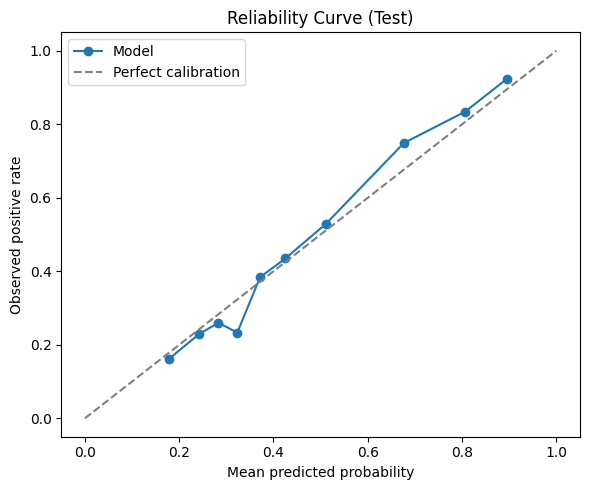

In [90]:
brier = brier_score_loss(y_test_A, test_proba)
print(f"Brier score (test): {brier:.4f}")

prob_true, prob_pred = calibration_curve(y_test_A, test_proba, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(prob_pred, prob_true, marker="o", label="Model")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.set_title("Reliability Curve (Test)")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed positive rate")
ax.legend()
fig.tight_layout()
plt.show()

## 4) Error analysis / failure modes
### - Top 20 false positives (highest predicted probability among negatives)
### - Top 20 false negatives (lowest predicted probability among positives)
### - Summaries for: poutcome, pdays, previous, balance
### - 2–3 short qualitative observations

In [91]:
# Build analysis dataframe from test set
test_analysis = X_test_A.copy().reset_index(drop=True)
test_analysis["y_true"] = pd.Series(y_test_A).reset_index(drop=True).astype(int)
test_analysis["proba_pos"] = pd.Series(test_proba).reset_index(drop=True)

# Thresholded predictions for FP/FN extraction
test_analysis["y_pred"] = (test_analysis["proba_pos"] >= best_threshold).astype(int)

# Top 20 false positives: true 0, predicted 1, sorted by highest proba
fp_df = test_analysis[(test_analysis["y_true"] == 0) & (test_analysis["y_pred"] == 1)] \
    .sort_values("proba_pos", ascending=False).head(20)

# Top 20 false negatives: true 1, predicted 0, sorted by lowest proba
fn_df = test_analysis[(test_analysis["y_true"] == 1) & (test_analysis["y_pred"] == 0)] \
    .sort_values("proba_pos", ascending=True).head(20)

print(f"False Positives selected: {len(fp_df)}")
print(f"False Negatives selected: {len(fn_df)}")

display_cols = [c for c in ["proba_pos", "y_true", "y_pred", "poutcome", "pdays", "previous", "balance"] if c in test_analysis.columns]

print("\nTop 20 False Positives (by highest predicted probability):")
print(fp_df[display_cols].head(20))

print("\nTop 20 False Negatives (by lowest predicted probability):")
print(fn_df[display_cols].head(20))

# %%
def summarize_group(group_df: pd.DataFrame, name: str) -> None:
    print("\n" + "=" * 70)
    print(f"{name} summary (n={len(group_df)})")
    print("=" * 70)
    if len(group_df) == 0:
        print("No rows in this error group.")
        return

    # Categorical summary: poutcome
    if "poutcome" in group_df.columns:
        print("\n'poutcome' distribution:")
        print(group_df["poutcome"].value_counts(dropna=False, normalize=True).round(3))

    # Numeric summaries
    for col in ["pdays", "previous", "balance"]:
        if col in group_df.columns:
            print(f"\n'{col}' summary:")
            print(group_df[col].describe())

    # Sentinel check for pdays == -1
    if "pdays" in group_df.columns:
        prop_neg1 = group_df["pdays"].eq(-1).mean()
        print(f"\nProportion with pdays == -1: {prop_neg1:.3f}")

summarize_group(fp_df, "False Positives")
summarize_group(fn_df, "False Negatives")

# %%
# Optional side-by-side medians for quick contrast (if numeric cols exist)
compare_cols = [c for c in ["pdays", "previous", "balance"] if c in test_analysis.columns]
if compare_cols and len(fp_df) > 0 and len(fn_df) > 0:
    compare_table = pd.DataFrame({
        "FP_median": fp_df[compare_cols].median(numeric_only=True),
        "FN_median": fn_df[compare_cols].median(numeric_only=True),
        "FP_mean": fp_df[compare_cols].mean(numeric_only=True),
        "FN_mean": fn_df[compare_cols].mean(numeric_only=True),
    })
    print("FP vs FN numeric comparison:")
    print(compare_table)

False Positives selected: 20
False Negatives selected: 20

Top 20 False Positives (by highest predicted probability):
      proba_pos  y_true  y_pred poutcome  pdays  previous  balance
1184   0.916983       0       1  success    181         2     2109
1665   0.903324       0       1  success    197         1     1854
705    0.900492       0       1  success     89         2      388
1865   0.899833       0       1  success     78         2    10086
1741   0.899617       0       1  success     91         5     2037
839    0.899448       0       1  success     82         1      390
764    0.899342       0       1  success     98         5      294
2122   0.898472       0       1  success     92         2     5763
1003   0.898041       0       1  success     94        15     2590
1425   0.894050       0       1  success     61         3        4
1332   0.893820       0       1  success     41         5     2337
487    0.888292       0       1  success    199         1        1
323    0.87